# Exploratory Data Analysis for Telco Customer Churn

This notebook documents the descriptive statistics and exploratory plots used to motivate the final Bayesian hierarchical logistic regression model. It is intentionally descriptive: the goal is to understand the cleaned data, identify obvious churn patterns, and justify later modeling choices such as excluding `TotalCharges` and grouping by contract type.

**How to run:** run the notebook from the project root. The data file is expected at `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import expit
from numpy.random import default_rng

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
OUTDIR = Path("data/telco_hier_logit_notebook_outputs")
OUTDIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)


## Setup

Load the standard scientific Python stack, define the data path, and set display/plotting defaults. No model is fit in this setup cell.


In [5]:
def load_and_prepare(csv_path: str):
    df = pd.read_csv(csv_path)
    raw_shape = df.shape

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")
    n_missing_total = df["TotalCharges"].isna().sum()

    df = df.drop(columns=["customerID"]).dropna().copy()
    df["Churn"] = (df["Churn"] == "Yes").astype(int)

    for col in ["Partner", "Dependents", "PaperlessBilling"]:
        df[col] = (df[col] == "Yes").astype(int)
    for col in ["OnlineSecurity", "TechSupport"]:
        df[col] = (df[col] == "Yes").astype(int)

    X = pd.DataFrame({
        "tenure": df["tenure"].astype(float),
        "MonthlyCharges": df["MonthlyCharges"].astype(float),
        "SeniorCitizen": df["SeniorCitizen"].astype(float),
        "Partner": df["Partner"].astype(float),
        "Dependents": df["Dependents"].astype(float),
        "PaperlessBilling": df["PaperlessBilling"].astype(float),
        "OnlineSecurity": df["OnlineSecurity"].astype(float),
        "TechSupport": df["TechSupport"].astype(float),
    })

    X = pd.concat(
        [
            X,
            pd.get_dummies(df["InternetService"], prefix="InternetService", drop_first=True, dtype=float),
            pd.get_dummies(df["PaymentMethod"], prefix="PaymentMethod", drop_first=True, dtype=float),
        ],
        axis=1,
    )

    feature_names = list(X.columns)

    continuous = ["tenure", "MonthlyCharges"]
    means = X[continuous].mean()
    sds = X[continuous].std()
    X.loc[:, continuous] = (X[continuous] - means) / sds

    y = df["Churn"].to_numpy(int)
    X_mat = X.to_numpy(float)

    contract_codes, contract_levels = pd.factorize(df["Contract"])

    info = {
        "raw_shape": raw_shape,
        "n_missing_totalcharges": int(n_missing_total),
        "clean_shape": df.shape,
        "overall_churn_rate": float(df["Churn"].mean()),
    }

    return {
        "df": df,
        "X_df": X,
        "X": X_mat,
        "y": y,
        "feature_names": feature_names,
        "contract_codes": contract_codes,
        "contract_levels": list(contract_levels),
        "means": means,
        "sds": sds,
        "info": info,
    }

data = load_and_prepare(DATA_PATH)
df = data["df"]
X_df = data["X_df"]
X = data["X"]
y = data["y"]
feature_names = data["feature_names"]
contract_codes = data["contract_codes"]
contract_levels = data["contract_levels"]

data["info"]


{'raw_shape': (7043, 21),
 'n_missing_totalcharges': 11,
 'clean_shape': (7032, 20),
 'overall_churn_rate': 0.26578498293515357}

## Data Cleaning and Feature Preparation

The cleaning steps mirror the final model notebook:

- Convert blank `TotalCharges` values to missing numeric values.
- Drop the 11 rows with missing `TotalCharges`.
- Remove `customerID`, which is only an identifier.
- Encode `Churn` as a binary 0/1 response.
- Convert selected yes/no predictors to binary indicators.

The helper function also builds a design matrix so this EDA notebook stays aligned with the modeling notebook.


In [7]:
import pandas as pd


df.head(3).T

,0,1,2
gender,Female,Male,Male
SeniorCitizen,0,0,0
Partner,1,0,0
Dependents,0,0,0
tenure,1,34,2
PhoneService,No,Yes,Yes
MultipleLines,No phone service,No,No
InternetService,DSL,DSL,DSL
OnlineSecurity,0,1,1
OnlineBackup,Yes,No,Yes


In [8]:
summary_table = pd.DataFrame({
    "n": [len(df)],
    "overall_churn_rate": [df["Churn"].mean()],
    "mean_tenure": [df["tenure"].mean()],
    "mean_monthly_charges": [df["MonthlyCharges"].mean()],
    "corr_tenure_totalcharges": [df[["tenure", "TotalCharges"]].corr().iloc[0, 1]],
    "corr_monthly_totalcharges": [df[["MonthlyCharges", "TotalCharges"]].corr().iloc[0, 1]],
})
summary_table.T


,0
n,7032.0000
overall_churn_rate,0.2658
mean_tenure,32.4218
mean_monthly_charges,64.7982
corr_tenure_totalcharges,0.8259
corr_monthly_totalcharges,0.6511


## First Look at the Cleaned Data

This transposed preview checks that categorical variables and binary encodings look sensible after cleaning.


In [10]:
# Basic info
n = len(df)
churn_rate = df["Churn"].mean()

print(f"Number of observations: {n}")
print(f"Overall churn rate: {churn_rate:.4f}")

Number of observations: 7032
Overall churn rate: 0.2658


## Overall Sample Summary

This table records the basic sample size, overall churn rate, and the collinearity diagnostics that justify excluding `TotalCharges` from the regression model.


In [12]:
continuous_cols = ["tenure", "MonthlyCharges"]

summary_stats = df[continuous_cols].describe().T
summary_stats["median"] = df[continuous_cols].median()

# Reorder columns nicely
summary_stats = summary_stats[["mean", "median", "std", "min", "25%", "50%", "75%", "max"]]

summary_stats

,mean,median,std,min,25%,50%,75%,max
tenure,32.4218,29.00,24.5453,1.00,9.0000,29.00,55.0000,72.00
MonthlyCharges,64.7982,70.35,30.0860,18.25,35.5875,70.35,89.8625,118.75


In [13]:
group_summary = df.groupby("Churn")[continuous_cols].agg([
    "mean", "median", "std"
])

group_summary

tenure                 MonthlyCharges                
          mean median      std           mean median      std
Churn                                                        
0      37.6500   38.0  24.0769        61.3074  64.45  31.0946
1      17.9791   10.0  19.5311        74.4413  79.65  24.6661

## Continuous Predictors

Tenure and monthly charges are the two continuous predictors retained in the final model. The grouped summaries compare their distributions for churned and non-churned customers.


In [15]:
summary_table = pd.DataFrame({
    "n": [len(df)],
    "overall_churn_rate": [df["Churn"].mean()],
    "mean_tenure": [df["tenure"].mean()],
    "median_tenure": [df["tenure"].median()],
    "std_tenure": [df["tenure"].std()],
    "mean_monthly_charges": [df["MonthlyCharges"].mean()],
    "median_monthly_charges": [df["MonthlyCharges"].median()],
    "std_monthly_charges": [df["MonthlyCharges"].std()],
    "corr_tenure_totalcharges": [df["tenure"].corr(df["TotalCharges"])],
    "corr_monthly_totalcharges": [df["MonthlyCharges"].corr(df["TotalCharges"])]
})

summary_table.T

,0
n,7032.0000
overall_churn_rate,0.2658
mean_tenure,32.4218
median_tenure,29.0000
std_tenure,24.5453
mean_monthly_charges,64.7982
median_monthly_charges,70.3500
std_monthly_charges,30.0860
corr_tenure_totalcharges,0.8259
corr_monthly_totalcharges,0.6511


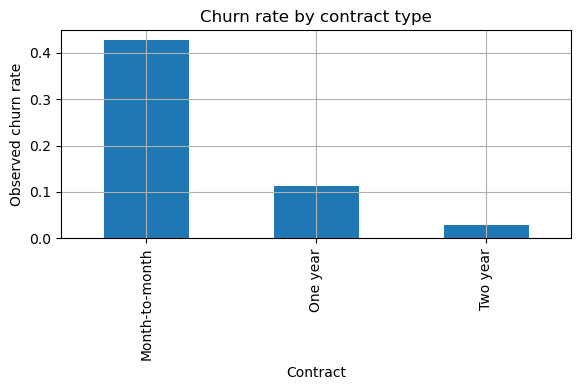

Contract
Month-to-month    0.4271
One year          0.1128
Two year          0.0285
Name: Churn, dtype: float64

In [16]:
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_internet = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
churn_by_contract.plot(kind="bar", ax=ax)
ax.set_ylabel("Observed churn rate")
ax.set_title("Churn rate by contract type")
plt.tight_layout()
plt.show()

churn_by_contract


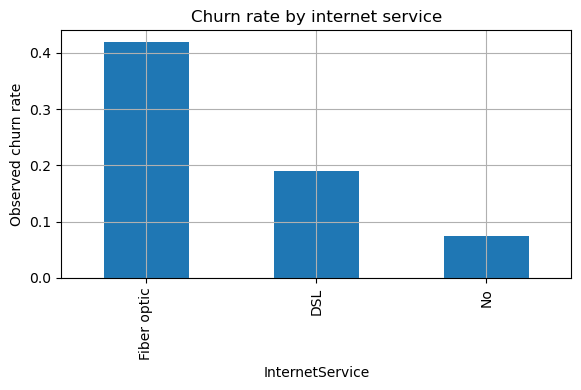

InternetService
Fiber optic    0.4189
DSL            0.1900
No             0.0743
Name: Churn, dtype: float64

In [17]:
fig, ax = plt.subplots()
churn_by_internet.plot(kind="bar", ax=ax)
ax.set_ylabel("Observed churn rate")
ax.set_title("Churn rate by internet service")
plt.tight_layout()
plt.show()

churn_by_internet


## Churn by Key Categorical Variables

Contract type and internet service show large differences in observed churn rates. These patterns motivate the contract-level hierarchy and internet-service fixed effects in the Bayesian model.


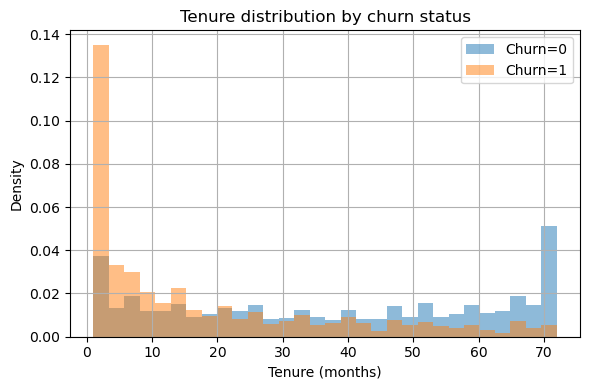

In [19]:
fig, ax = plt.subplots()
for value, grp in df.groupby("Churn"):
    ax.hist(grp["tenure"], bins=30, alpha=0.5, density=True, label=f"Churn={value}")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Density")
ax.set_title("Tenure distribution by churn status")
ax.legend()
plt.tight_layout()
plt.show()


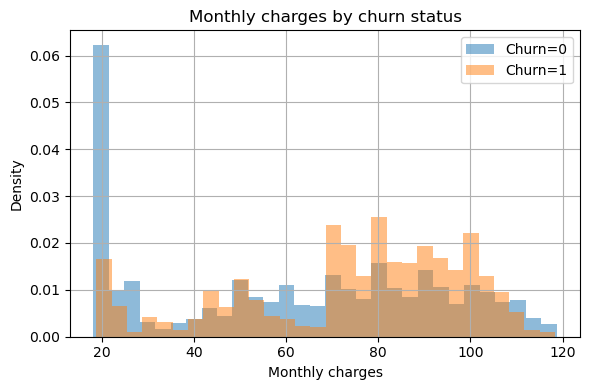

In [20]:
fig, ax = plt.subplots()
for value, grp in df.groupby("Churn"):
    ax.hist(grp["MonthlyCharges"], bins=30, alpha=0.5, density=True, label=f"Churn={value}")
ax.set_xlabel("Monthly charges")
ax.set_ylabel("Density")
ax.set_title("Monthly charges by churn status")
ax.legend()
plt.tight_layout()
plt.show()


## Distributional Plots by Churn Status

These histograms show that churned customers tend to have shorter tenure and somewhat higher monthly charges. The final model uses standardized versions of these variables so their coefficients are easier to estimate and compare.


## Export Report EDA Figure

The final report uses a compact four-panel EDA figure. This cell generates the exact file included in the writeup: `figures/eda_churn_rates.pdf`. Keeping the figure creation here makes the report traceable to the notebook analysis.


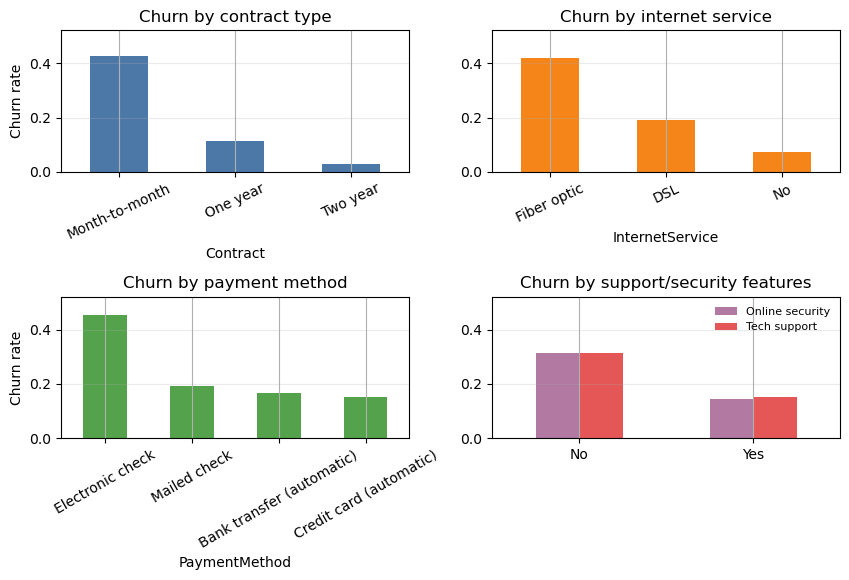

In [23]:
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(8.6, 5.9))

churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_contract.plot(kind="bar", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Churn by contract type")
axes[0, 0].set_ylabel("Churn rate")
axes[0, 0].tick_params(axis="x", rotation=25)

churn_by_internet = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
churn_by_internet.plot(kind="bar", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Churn by internet service")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis="x", rotation=25)

payment_summary = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
payment_summary.plot(kind="bar", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Churn by payment method")
axes[1, 0].set_ylabel("Churn rate")
axes[1, 0].tick_params(axis="x", rotation=30)

support_summary = pd.DataFrame({
    "Online security": df.groupby("OnlineSecurity")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
    "Tech support": df.groupby("TechSupport")["Churn"].mean().rename(index={0: "No", 1: "Yes"}),
})
support_summary.plot(kind="bar", ax=axes[1, 1], color=["#B279A2", "#E45756"])
axes[1, 1].set_title("Churn by support/security features")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(frameon=False, fontsize=8)

for ax in axes.ravel():
    ax.set_ylim(0, max(ax.get_ylim()[1], 0.52))
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(FIG_DIR / "eda_churn_rates.pdf", bbox_inches="tight")
plt.show()


## EDA Takeaways

The exploratory analysis supports the final model specification:

- The cleaned data contain 7032 customers with an overall churn rate of about 26.6%.
- Contract type is strongly associated with churn, motivating group-specific baseline intercepts.
- Fiber optic service has higher observed churn than DSL or no internet service.
- Customers who churn tend to have shorter tenure and higher monthly charges.
- `TotalCharges` is highly correlated with tenure and monthly charges, so excluding it improves coefficient interpretability.

These findings are descriptive, not causal; they are used to guide the regression model rather than to claim direct causal effects.
